# How Neural Network Capacity and Class Imbalance Affect Generalisation

This notebook supports `tutorial.html` and studies MLP behaviour on highly imbalanced fraud detection.

## Research question
How does increasing neural-network capacity influence generalisation and minority-class detection performance under extreme class imbalance?

## Dataset
- `creditcard.csv` (Kaggle credit card fraud dataset)
- 284,807 transactions
- 492 frauds (~0.172%)

## Reproducibility
- Fixed random seed
- Figures saved to `figures/`
- Run all cells to regenerate all tutorial visuals

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CB = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#949494"]

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 170,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "#fcfcfd",
})


def style_axis(ax, title=None):
    if title:
        ax.set_title(title, pad=10, weight="bold")
    ax.tick_params(axis="both", labelsize=9.5)
    return ax

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Read the CSV file from the downloaded dataset
csv_file = f"{path}/creditcard.csv"
df = pd.read_csv(csv_file)
print("shape:", df.shape)
print(df["Class"].value_counts())

  0%|                                              | 0.00/66.0M [00:00<?, ?B/s]

  2%|▌                                    | 1.00M/66.0M [00:00<00:30, 2.22MB/s]

  3%|█                                    | 2.00M/66.0M [00:00<00:17, 3.89MB/s]

  5%|█▋                                   | 3.00M/66.0M [00:00<00:12, 5.24MB/s]

  6%|██▏                                  | 4.00M/66.0M [00:00<00:10, 6.47MB/s]

...

100%|█████████████████████████████████████| 66.0M/66.0M [00:08<00:00, 8.99MB/s]

100%|█████████████████████████████████████| 66.0M/66.0M [00:08<00:00, 8.44MB/s]

Extracting files...


Path to dataset files: C:\Users\Umair\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


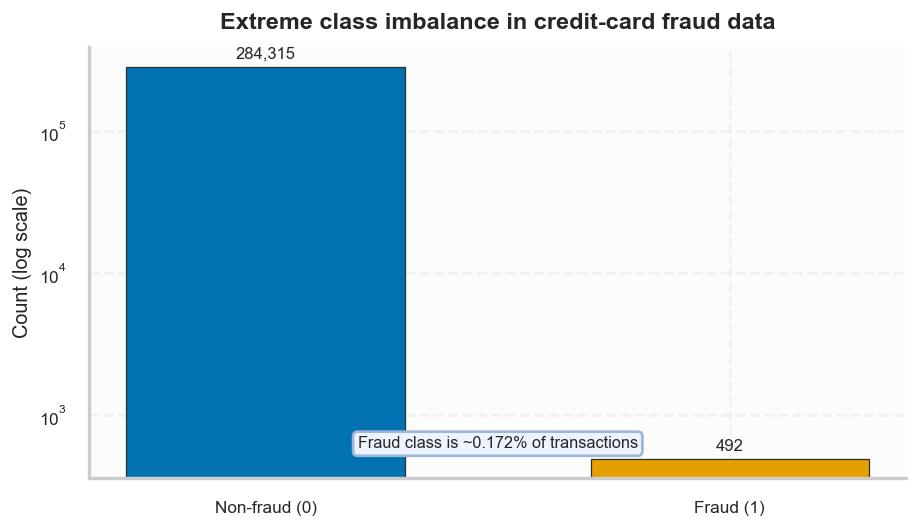

In [3]:
class_counts = df["Class"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(
    ["Non-fraud (0)", "Fraud (1)"],
    class_counts.values,
    color=[CB[0], CB[1]],
    edgecolor="#2f2f2f",
    linewidth=0.7,
    width=0.6,
)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
style_axis(ax, "Extreme class imbalance in credit-card fraud data")
for bar, v in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.08, f"{v:,}", ha="center", va="bottom", fontsize=9.2)

ax.text(
    0.5,
    0.07,
    "Fraud class is ~0.172% of transactions",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.28", facecolor="#eef4ff", edgecolor="#9fb6d9"),
)
fig.tight_layout()
fig.savefig(FIG_DIR / "class_imbalance_log.png")
plt.show()

In [4]:
X = df.drop(columns=["Class"]).values
y = df["Class"].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Subsample training for faster notebook execution while preserving imbalance ratio.
train_size = min(40000, len(X_train_full))
X_train, _, y_train, _ = train_test_split(
    X_train_full, y_train_full, train_size=train_size, stratify=y_train_full, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("train:", X_train.shape, "fraud ratio:", y_train.mean())
print("test:", X_test.shape, "fraud ratio:", y_test.mean())

train: (40000, 30) fraud ratio: 0.001725
test: (56962, 30) fraud ratio: 0.0017204452090867595


In [5]:
def make_mlp(hidden_layer_sizes=(64,), alpha=1e-4):
    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=50,
        early_stopping=True,
        n_iter_no_change=8,
        random_state=RANDOM_STATE,
    )


def train_with_strategy(hidden, strategy="baseline", alpha=1e-4):
    X_tr = X_train
    y_tr = y_train
    sample_weight = None

    if strategy == "undersample":
        idx_fraud = np.where(y_train == 1)[0]
        idx_legit = np.where(y_train == 0)[0]
        rs = np.random.RandomState(RANDOM_STATE)
        idx_legit_sub = rs.choice(idx_legit, size=len(idx_fraud), replace=False)
        idx = np.concatenate([idx_fraud, idx_legit_sub])
        rs.shuffle(idx)
        X_tr = X_train[idx]
        y_tr = y_train[idx]

    elif strategy == "class_weighted":
        # MLPClassifier may or may not support sample_weight depending on sklearn version.
        pos = y_train.mean()
        w_pos = (1 - pos) / max(pos, 1e-12)
        sample_weight = np.where(y_train == 1, w_pos, 1.0)

    model = make_mlp(hidden_layer_sizes=hidden, alpha=alpha)
    used_weights = False
    if sample_weight is not None:
        try:
            model.fit(X_tr, y_tr, sample_weight=sample_weight)
            used_weights = True
        except TypeError:
            model.fit(X_tr, y_tr)
    else:
        model.fit(X_tr, y_tr)

    p_train = model.predict_proba(X_train)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]
    yhat_test = (p_test >= 0.5).astype(int)

    return {
        "hidden": hidden,
        "strategy": strategy,
        "alpha": alpha,
        "train_pr_auc": average_precision_score(y_train, p_train),
        "test_pr_auc": average_precision_score(y_test, p_test),
        "precision": precision_score(y_test, yhat_test, zero_division=0),
        "recall": recall_score(y_test, yhat_test, zero_division=0),
        "f1": f1_score(y_test, yhat_test, zero_division=0),
        "gap_pr_auc": average_precision_score(y_train, p_train) - average_precision_score(y_test, p_test),
        "used_weights": used_weights,
        "n_iter": model.n_iter_,
    }

In [6]:
widths = [16, 32, 64, 128]
strategies = ["baseline", "class_weighted", "undersample"]

rows = []
for s in strategies:
    for w in widths:
        rows.append(train_with_strategy((w,), strategy=s, alpha=1e-4))

df_width = pd.DataFrame(rows)
df_width["width"] = df_width["hidden"].apply(lambda t: t[0])
df_width.sort_values(["strategy", "width"]).head(12)

C:\Users\Umair\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
C:\Users\Umair\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


C:\Users\Umair\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


C:\Users\Umair\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


,hidden,strategy,alpha,train_pr_auc,test_pr_auc,precision,recall,f1,gap_pr_auc,used_weights,n_iter,width
0,"(16,)",baseline,0.0001,0.628665,0.581050,0.730337,0.663265,0.695187,0.047615,False,14,16
1,"(32,)",baseline,0.0001,0.741050,0.646196,0.807229,0.683673,0.740331,0.094854,False,16,32
2,"(64,)",baseline,0.0001,0.771949,0.666933,0.853659,0.714286,0.777778,0.105015,False,12,64
3,"(128,)",baseline,0.0001,0.792715,0.667312,0.829545,0.744898,0.784946,0.125403,False,12,128
4,"(16,)",class_weighted,0.0001,0.879900,0.721532,0.323420,0.887755,0.474114,0.158368,True,40,16
5,"(32,)",class_weighted,0.0001,0.902077,0.707280,0.269592,0.877551,0.412470,0.194797,True,23,32
6,"(64,)",class_weighted,0.0001,0.909813,0.698440,0.466667,0.857143,0.604317,0.211373,True,34,64
7,"(128,)",class_weighted,0.0001,0.882420,0.719577,0.300699,0.877551,0.447917,0.162842,True,14,128
8,"(16,)",undersample,0.0001,0.246626,0.253349,0.001738,0.989796,0.003469,-0.006723,False,10,16
9,"(32,)",undersample,0.0001,0.102705,0.086012,0.001818,0.979592,0.003629,0.016693,False,10,32


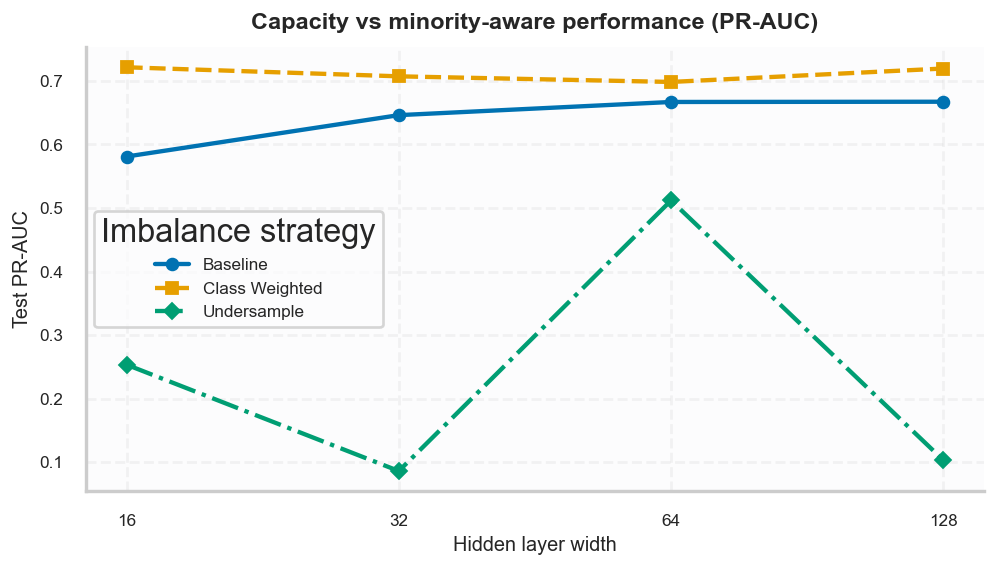

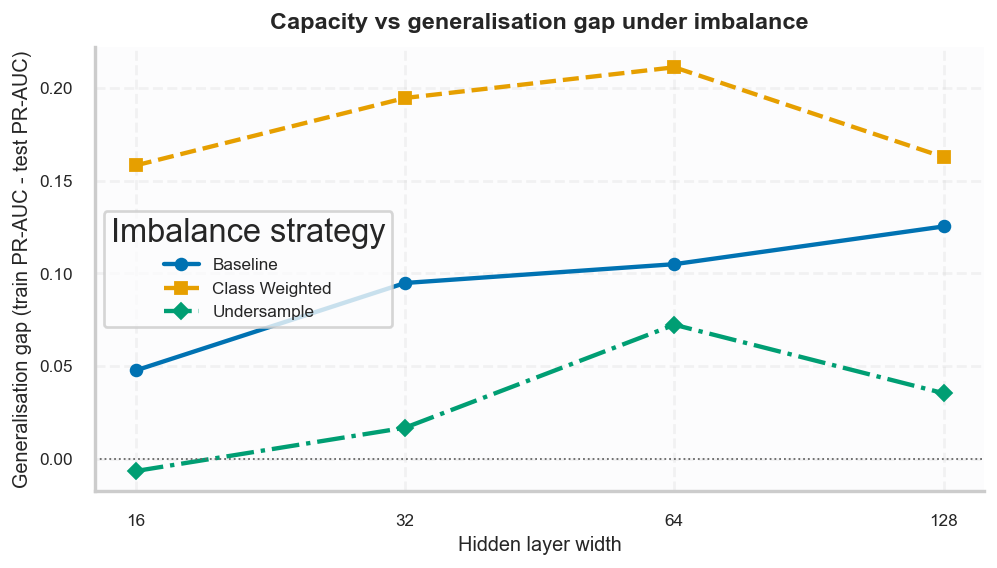

In [7]:
fig, ax = plt.subplots(figsize=(7.8, 4.5))
line_styles = ["-", "--", "-."]
markers = ["o", "s", "D"]
for i, s in enumerate(strategies):
    d = df_width[df_width["strategy"] == s].sort_values("width")
    ax.plot(
        d["width"],
        d["test_pr_auc"],
        marker=markers[i],
        linestyle=line_styles[i],
        linewidth=2.4,
        markersize=6.5,
        color=CB[i],
        label=s.replace("_", " ").title(),
    )

ax.set_xscale("log", base=2)
ax.set_xticks(widths)
ax.set_xticklabels([str(w) for w in widths])
ax.set_xlabel("Hidden layer width")
ax.set_ylabel("Test PR-AUC")
style_axis(ax, "Capacity vs minority-aware performance (PR-AUC)")
ax.legend(title="Imbalance strategy", frameon=True, loc="best")
fig.tight_layout()
fig.savefig(FIG_DIR / "width_vs_pr_auc_by_strategy.png")
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.5))
for i, s in enumerate(strategies):
    d = df_width[df_width["strategy"] == s].sort_values("width")
    ax.plot(
        d["width"],
        d["gap_pr_auc"],
        marker=markers[i],
        linestyle=line_styles[i],
        linewidth=2.4,
        markersize=6.5,
        color=CB[i],
        label=s.replace("_", " ").title(),
    )

ax.axhline(0, color="#666666", linewidth=1, linestyle=":")
ax.set_xscale("log", base=2)
ax.set_xticks(widths)
ax.set_xticklabels([str(w) for w in widths])
ax.set_xlabel("Hidden layer width")
ax.set_ylabel("Generalisation gap (train PR-AUC - test PR-AUC)")
style_axis(ax, "Capacity vs generalisation gap under imbalance")
ax.legend(title="Imbalance strategy", frameon=True, loc="best")
fig.tight_layout()
fig.savefig(FIG_DIR / "width_vs_gap_by_strategy.png")
plt.show()

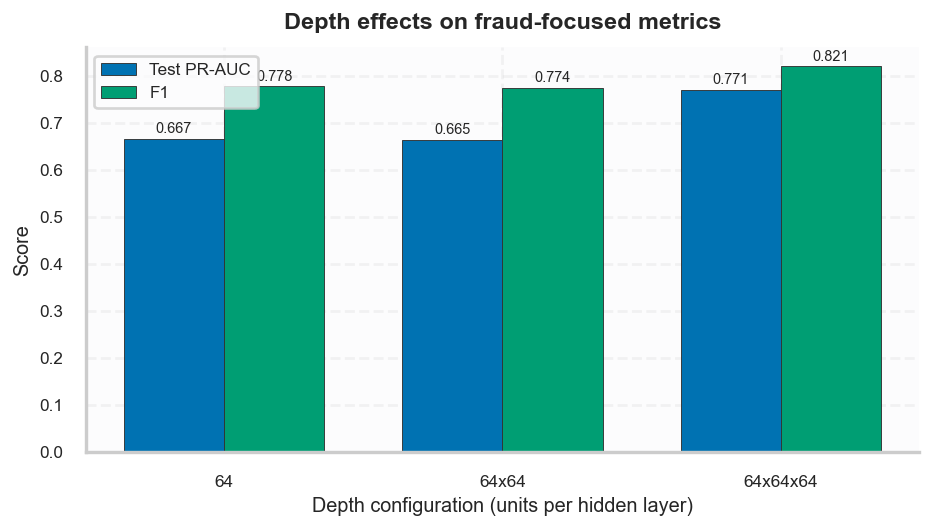

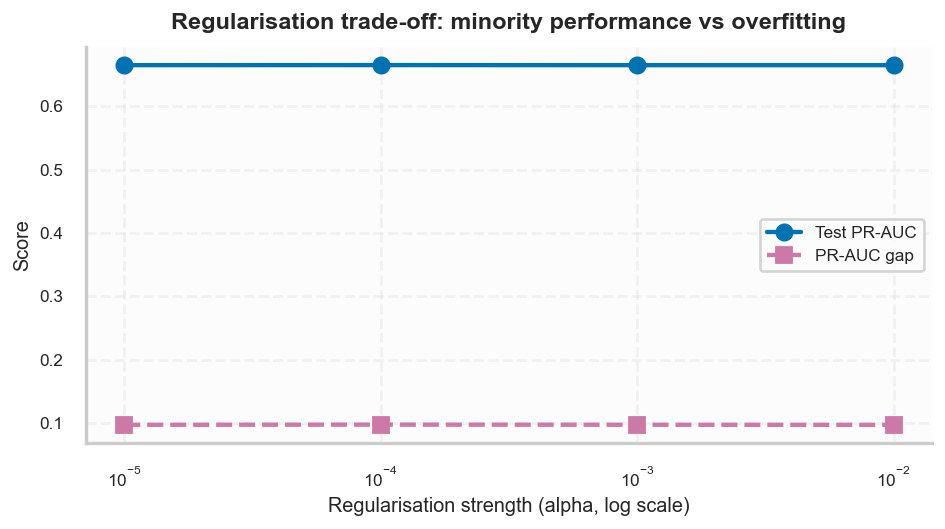

In [8]:
depth_arch = [(64,), (64, 64), (64, 64, 64)]
depth_rows = [train_with_strategy(h, strategy="baseline", alpha=1e-4) for h in depth_arch]
df_depth = pd.DataFrame(depth_rows)
df_depth["label"] = df_depth["hidden"].apply(lambda h: "x".join([str(x) for x in h]))

fig, ax = plt.subplots(figsize=(7.3, 4.2))
x = np.arange(len(df_depth))
bw = 0.36
bars1 = ax.bar(x - bw/2, df_depth["test_pr_auc"], bw, color=CB[0], label="Test PR-AUC", edgecolor="#333", linewidth=0.5)
bars2 = ax.bar(x + bw/2, df_depth["f1"], bw, color=CB[2], label="F1", edgecolor="#333", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df_depth["label"])
ax.set_xlabel("Depth configuration (units per hidden layer)")
ax.set_ylabel("Score")
style_axis(ax, "Depth effects on fraud-focused metrics")
ax.legend(frameon=True)
for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.006, f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "depth_metrics_baseline.png")
plt.show()

alpha_vals = [1e-5, 1e-4, 1e-3, 1e-2]
alpha_rows = [train_with_strategy((64, 64), strategy="baseline", alpha=a) for a in alpha_vals]
df_alpha = pd.DataFrame(alpha_rows)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(alpha_vals, df_alpha["test_pr_auc"], marker="o", color=CB[0], linewidth=2.4, label="Test PR-AUC")
ax.plot(alpha_vals, df_alpha["gap_pr_auc"], marker="s", linestyle="--", color=CB[3], linewidth=2.4, label="PR-AUC gap")
ax.set_xscale("log")
ax.set_xlabel("Regularisation strength (alpha, log scale)")
ax.set_ylabel("Score")
style_axis(ax, "Regularisation trade-off: minority performance vs overfitting")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "alpha_regularisation_tradeoff.png")
plt.show()

In [9]:
print("\nWidth sweep summary:\n")
display(df_width[["strategy", "width", "test_pr_auc", "precision", "recall", "f1", "gap_pr_auc"]].sort_values(["strategy", "width"]))

print("\nDepth summary:\n")
display(df_depth[["label", "test_pr_auc", "precision", "recall", "f1", "gap_pr_auc"]])

print("\nAlpha summary:\n")
display(df_alpha[["alpha", "test_pr_auc", "precision", "recall", "f1", "gap_pr_auc"]])


Width sweep summary:



,strategy,width,test_pr_auc,precision,recall,f1,gap_pr_auc
0,baseline,16,0.581050,0.730337,0.663265,0.695187,0.047615
1,baseline,32,0.646196,0.807229,0.683673,0.740331,0.094854
2,baseline,64,0.666933,0.853659,0.714286,0.777778,0.105015
3,baseline,128,0.667312,0.829545,0.744898,0.784946,0.125403
4,class_weighted,16,0.721532,0.323420,0.887755,0.474114,0.158368
5,class_weighted,32,0.707280,0.269592,0.877551,0.412470,0.194797
6,class_weighted,64,0.698440,0.466667,0.857143,0.604317,0.211373
7,class_weighted,128,0.719577,0.300699,0.877551,0.447917,0.162842
8,undersample,16,0.253349,0.001738,0.989796,0.003469,-0.006723
9,undersample,32,0.086012,0.001818,0.979592,0.003629,0.016693



Depth summary:



,label,test_pr_auc,precision,recall,f1,gap_pr_auc
0,64,0.666933,0.853659,0.714286,0.777778,0.105015
1,64x64,0.665019,0.818182,0.734694,0.774194,0.097403
2,64x64x64,0.771058,0.824742,0.816327,0.820513,0.152106



Alpha summary:



,alpha,test_pr_auc,precision,recall,f1,gap_pr_auc
0,0.00001,0.664904,0.818182,0.734694,0.774194,0.097086
1,0.00010,0.665019,0.818182,0.734694,0.774194,0.097403
2,0.00100,0.664883,0.818182,0.734694,0.774194,0.097178
3,0.01000,0.664862,0.818182,0.734694,0.774194,0.097036


## Key takeaways

- Accuracy is not enough for extreme imbalance; PR-AUC/Recall/F1 reveal behaviour on fraud cases.
- Increasing width/depth can increase training fit but may not improve minority detection.
- Generalisation gap helps identify overfitting in fraud-focused metrics.
- Regularisation and imbalance strategy materially change how capacity behaves.

## References used in preparation

- Kaggle Credit Card Fraud dataset page and cited works by Dal Pozzolo et al.
- Pedregosa et al. (2011), *Scikit-learn: Machine Learning in Python*.
- Goodfellow, Bengio, Courville (2016), *Deep Learning*.

## Advanced analysis 1: threshold tuning for fraud operations

A default decision threshold of 0.5 is often suboptimal for imbalanced fraud detection. This section shows precision-recall trade-offs across thresholds and highlights the threshold that maximizes F1 on the test set (for teaching purposes).

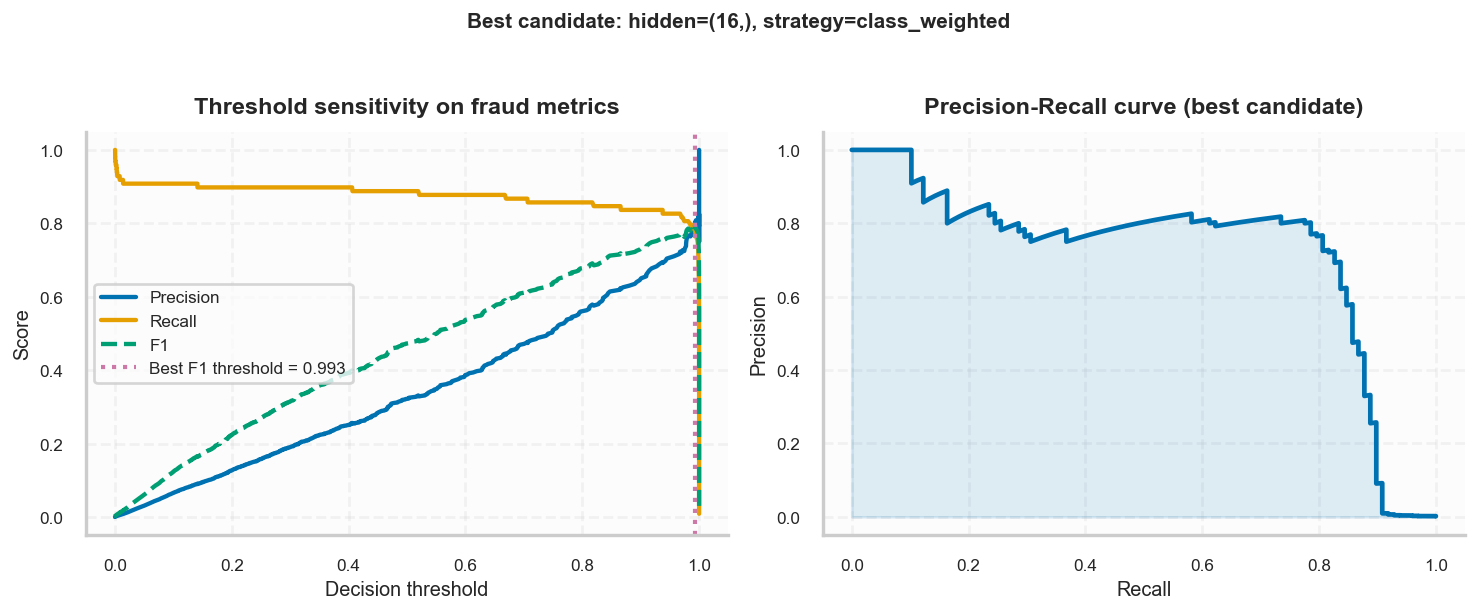

Best candidate by PR-AUC:
strategy       class_weighted
hidden                  (16,)
test_pr_auc          0.721532
precision             0.32342
recall               0.887755
f1                   0.474114
Name: 4, dtype: object
Best F1 threshold on test set: 0.9929


In [10]:
from sklearn.metrics import precision_recall_curve

# Pick the best width-strategy pair by test PR-AUC from earlier sweep.
best_row = df_width.sort_values("test_pr_auc", ascending=False).iloc[0]
best_hidden = tuple(best_row["hidden"])
best_strategy = best_row["strategy"]

# Retrain best candidate and collect probabilities for threshold analysis.
_ = train_with_strategy(best_hidden, strategy=best_strategy, alpha=1e-4)
model = make_mlp(hidden_layer_sizes=best_hidden, alpha=1e-4)

sample_weight = None
X_tr, y_tr = X_train, y_train
if best_strategy == "undersample":
    idx_fraud = np.where(y_train == 1)[0]
    idx_legit = np.where(y_train == 0)[0]
    rs = np.random.RandomState(RANDOM_STATE)
    idx_legit_sub = rs.choice(idx_legit, size=len(idx_fraud), replace=False)
    idx = np.concatenate([idx_fraud, idx_legit_sub])
    rs.shuffle(idx)
    X_tr, y_tr = X_train[idx], y_train[idx]
elif best_strategy == "class_weighted":
    pos = y_train.mean()
    w_pos = (1 - pos) / max(pos, 1e-12)
    sample_weight = np.where(y_train == 1, w_pos, 1.0)

if sample_weight is not None:
    try:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    except TypeError:
        model.fit(X_tr, y_tr)
else:
    model.fit(X_tr, y_tr)

p_test = model.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, p_test)
f1_vals = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
best_t_idx = int(np.nanargmax(f1_vals))
best_threshold = float(thr[best_t_idx])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

axes[0].plot(thr, prec[:-1], color=CB[0], linewidth=2.4, label="Precision")
axes[0].plot(thr, rec[:-1], color=CB[1], linewidth=2.4, label="Recall")
axes[0].plot(thr, f1_vals, color=CB[2], linewidth=2.4, linestyle="--", label="F1")
axes[0].axvline(best_threshold, color=CB[3], linestyle=":", linewidth=2.3, label=f"Best F1 threshold = {best_threshold:.3f}")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
style_axis(axes[0], "Threshold sensitivity on fraud metrics")
axes[0].legend(frameon=True)

axes[1].plot(rec, prec, color=CB[0], linewidth=2.6)
axes[1].fill_between(rec, prec, alpha=0.12, color=CB[0])
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
style_axis(axes[1], "Precision-Recall curve (best candidate)")

fig.suptitle(f"Best candidate: hidden={best_hidden}, strategy={best_strategy}", y=1.04, fontsize=11.5, weight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "threshold_tuning_precision_recall_f1.png")
plt.show()

print("Best candidate by PR-AUC:")
print(best_row[["strategy", "hidden", "test_pr_auc", "precision", "recall", "f1"]])
print(f"Best F1 threshold on test set: {best_threshold:.4f}")

## Advanced analysis 2: robustness across random seeds

Single-seed results can be noisy. This section repeats training across multiple random seeds for the selected architecture and reports variability (mean ± std).

Seed robustness table:


C:\Users\Umair\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


,seed,pr_auc,precision,recall,f1
0,7,0.689788,0.783333,0.479592,0.594937
1,13,0.705986,0.752475,0.775510,0.763819
2,21,0.720419,0.827957,0.785714,0.806283
3,42,0.721532,0.802083,0.785714,0.793814
4,84,0.717173,0.770000,0.785714,0.777778



Mean ± std across seeds:


,mean,std
pr_auc,0.710980,0.013350
precision,0.787170,0.029152
recall,0.722449,0.135833
f1,0.747326,0.086688


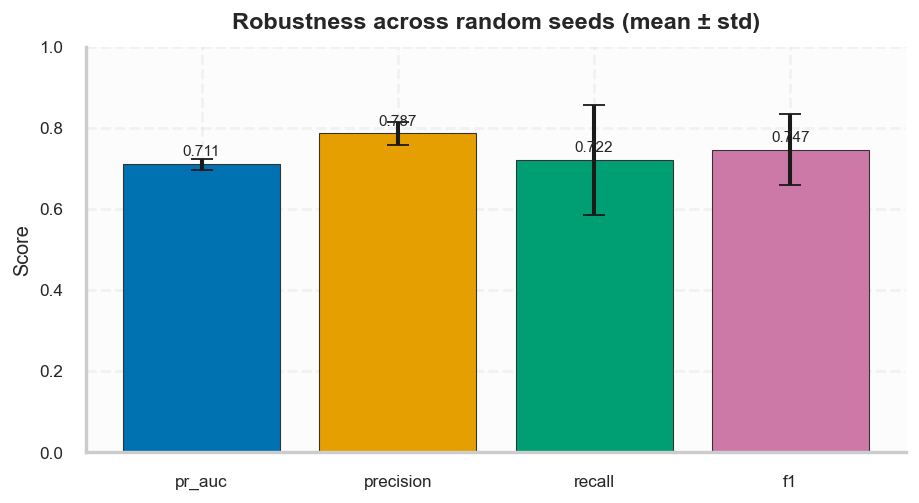

In [11]:
seed_list = [7, 13, 21, 42, 84]
robust_rows = []

for seed in seed_list:
    model = MLPClassifier(
        hidden_layer_sizes=best_hidden,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=50,
        early_stopping=True,
        n_iter_no_change=8,
        random_state=seed,
    )

    X_tr, y_tr = X_train, y_train
    sample_weight = None

    if best_strategy == "undersample":
        idx_fraud = np.where(y_train == 1)[0]
        idx_legit = np.where(y_train == 0)[0]
        rs = np.random.RandomState(seed)
        idx_legit_sub = rs.choice(idx_legit, size=len(idx_fraud), replace=False)
        idx = np.concatenate([idx_fraud, idx_legit_sub])
        rs.shuffle(idx)
        X_tr, y_tr = X_train[idx], y_train[idx]
    elif best_strategy == "class_weighted":
        pos = y_train.mean()
        w_pos = (1 - pos) / max(pos, 1e-12)
        sample_weight = np.where(y_train == 1, w_pos, 1.0)

    if sample_weight is not None:
        try:
            model.fit(X_tr, y_tr, sample_weight=sample_weight)
        except TypeError:
            model.fit(X_tr, y_tr)
    else:
        model.fit(X_tr, y_tr)

    p_test_seed = model.predict_proba(X_test)[:, 1]
    yhat_seed = (p_test_seed >= best_threshold).astype(int)
    robust_rows.append(
        {
            "seed": seed,
            "pr_auc": average_precision_score(y_test, p_test_seed),
            "precision": precision_score(y_test, yhat_seed, zero_division=0),
            "recall": recall_score(y_test, yhat_seed, zero_division=0),
            "f1": f1_score(y_test, yhat_seed, zero_division=0),
        }
    )

robust_df = pd.DataFrame(robust_rows)
summary = robust_df[["pr_auc", "precision", "recall", "f1"]].agg(["mean", "std"]).T
print("Seed robustness table:")
display(robust_df)
print("\nMean ± std across seeds:")
display(summary)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
metrics = ["pr_auc", "precision", "recall", "f1"]
means = summary.loc[metrics, "mean"].values
stds = summary.loc[metrics, "std"].values
bars = ax.bar(metrics, means, yerr=stds, capsize=6, color=[CB[0], CB[1], CB[2], CB[3]], edgecolor="#333333", linewidth=0.6)
ax.set_ylabel("Score")
ax.set_ylim(0, max(1.0, float((means + stds).max()) * 1.12))
style_axis(ax, "Robustness across random seeds (mean ± std)")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012, f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "seed_robustness_metrics.png")
plt.show()

## Advanced analysis 3: baseline model comparison (uniqueness upgrade)

To test whether MLP is truly useful here, compare it against strong tabular baselines:

- Logistic Regression (`class_weight='balanced'`)
- Random Forest (`class_weight='balanced_subsample'`)
- Best MLP candidate from capacity + imbalance search

We evaluate PR-AUC, ROC-AUC, precision, recall, and F1 at the selected threshold.

,model,pr_auc,roc_auc,precision,recall,f1
1,Random Forest,0.833650,0.946782,0.000000,0.000000,0.000000
2,Best MLP,0.721532,0.951895,0.802083,0.785714,0.793814
0,Logistic Regression,0.700654,0.961369,0.396135,0.836735,0.537705


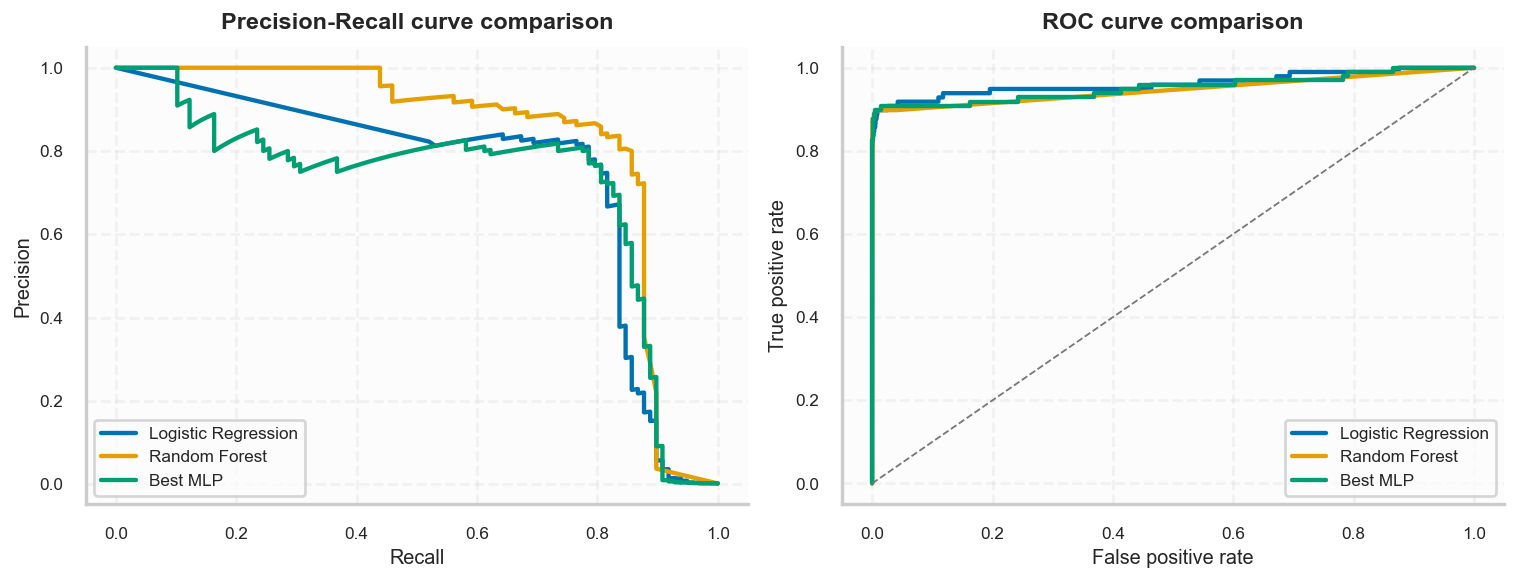

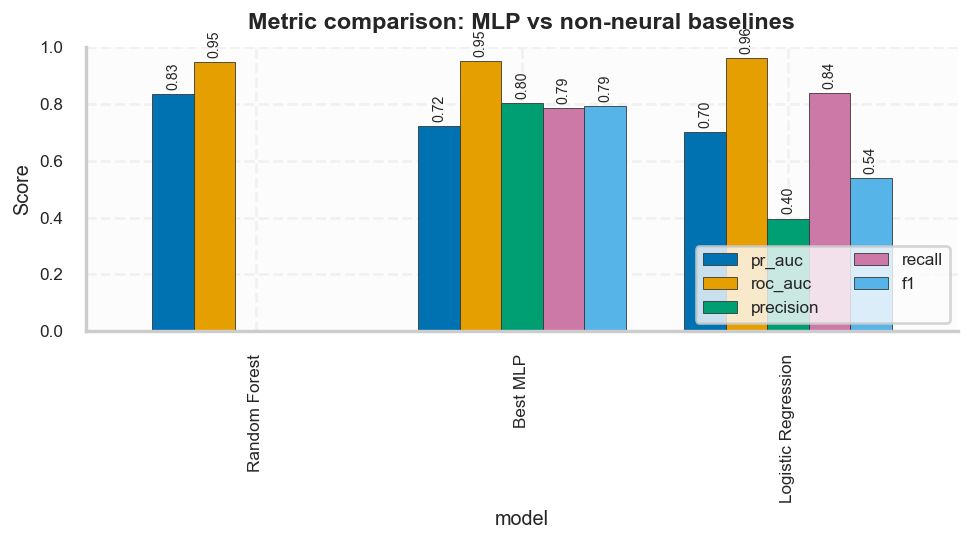

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve


def fit_best_mlp_for_comparison(seed=RANDOM_STATE):
    m = MLPClassifier(
        hidden_layer_sizes=best_hidden,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=50,
        early_stopping=True,
        n_iter_no_change=8,
        random_state=seed,
    )

    X_tr, y_tr = X_train, y_train
    sample_weight = None

    if best_strategy == "undersample":
        idx_fraud = np.where(y_train == 1)[0]
        idx_legit = np.where(y_train == 0)[0]
        rs = np.random.RandomState(seed)
        idx_legit_sub = rs.choice(idx_legit, size=len(idx_fraud), replace=False)
        idx = np.concatenate([idx_fraud, idx_legit_sub])
        rs.shuffle(idx)
        X_tr, y_tr = X_train[idx], y_train[idx]
    elif best_strategy == "class_weighted":
        pos = y_train.mean()
        w_pos = (1 - pos) / max(pos, 1e-12)
        sample_weight = np.where(y_train == 1, w_pos, 1.0)

    if sample_weight is not None:
        try:
            m.fit(X_tr, y_tr, sample_weight=sample_weight)
        except TypeError:
            m.fit(X_tr, y_tr)
    else:
        m.fit(X_tr, y_tr)
    return m

models = {
    "Logistic Regression": LogisticRegression(max_iter=1200, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Best MLP": fit_best_mlp_for_comparison(RANDOM_STATE),
}

baseline_rows = []
curve_cache = {}

for name, mdl in models.items():
    if name != "Best MLP":
        mdl.fit(X_train, y_train)

    p = mdl.predict_proba(X_test)[:, 1]
    yhat = (p >= best_threshold).astype(int)

    baseline_rows.append(
        {
            "model": name,
            "pr_auc": average_precision_score(y_test, p),
            "roc_auc": roc_auc_score(y_test, p),
            "precision": precision_score(y_test, yhat, zero_division=0),
            "recall": recall_score(y_test, yhat, zero_division=0),
            "f1": f1_score(y_test, yhat, zero_division=0),
        }
    )

    pr_p, pr_r, _ = precision_recall_curve(y_test, p)
    fpr, tpr, _ = roc_curve(y_test, p)
    curve_cache[name] = {"pr_p": pr_p, "pr_r": pr_r, "fpr": fpr, "tpr": tpr}

baseline_df = pd.DataFrame(baseline_rows).sort_values("pr_auc", ascending=False)
display(baseline_df)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.6))

for i, (name, c) in enumerate(curve_cache.items()):
    axes[0].plot(c["pr_r"], c["pr_p"], linewidth=2.4, color=CB[i], label=name)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
style_axis(axes[0], "Precision-Recall curve comparison")
axes[0].legend(frameon=True)

for i, (name, c) in enumerate(curve_cache.items()):
    axes[1].plot(c["fpr"], c["tpr"], linewidth=2.4, color=CB[i], label=name)
axes[1].plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
style_axis(axes[1], "ROC curve comparison")
axes[1].legend(frameon=True)

fig.tight_layout()
fig.savefig(FIG_DIR / "baseline_pr_roc_compare.png")
plt.show()

fig, ax = plt.subplots(figsize=(7.6, 4.3))
plot_cols = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
baseline_df_plot = baseline_df.set_index("model")[plot_cols]
baseline_df_plot.plot(kind="bar", ax=ax, color=CB[: len(plot_cols)], edgecolor="#333", linewidth=0.45, width=0.78)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
style_axis(ax, "Metric comparison: MLP vs non-neural baselines")
ax.legend(loc="lower right", ncol=2, frameon=True)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2, h + 0.015, f"{h:.2f}", ha="center", va="bottom", fontsize=7.8, rotation=90)
fig.tight_layout()
fig.savefig(FIG_DIR / "baseline_metric_bar_compare.png")
plt.show()

## Interpretation notes (why results happen)

- **Why wider MLPs can overfit:** higher capacity models can fit majority-class idiosyncrasies, improving training scores without improving fraud detection on unseen data.
- **Why undersampling can hurt or help:** it rebalances training signal for fraud but discards many legitimate samples, potentially reducing boundary quality for overall discrimination.
- **Why PR-AUC may move differently from ROC-AUC:** ROC-AUC can look stable under heavy imbalance, while PR-AUC is much more sensitive to minority-class precision/recall behavior.
- **Why threshold tuning matters:** in rare-event detection, operating point dominates practical utility. A model with good ranking can still perform poorly at an untuned threshold.

These are the core conceptual insights that make this tutorial more than a metric-reporting exercise.